# Multiscale Effects of Dust on UV–FIR Emission at z = 7

This notebook is part of the **CCDC26 tutorial** on how to model the multiscale
effects of dust on galaxy emission from UV to FIR. It extends the z=10 analysis to **z=7** and adds predictions for the
**infrared luminosity function** and **greybody far-IR SEDs**,
completing the picture of how dust shapes galaxy emission from rest-frame UV to FIR.

At z=7, T_CMB = 2.73 × (1+7) ≈ 22 K sets a floor on dust temperatures,
and ALMA routinely detects z ~ 7 galaxies in [CII] 158 µm continuum —
so the IR SED is directly observable, unlike at z=10.

**Note:** grain microphysics (single-grain κ(λ), grain size distributions, and RT
attenuation curves) are computed in the companion notebook
`notebook_dust_lf_cph26_z10.ipynb`, which also saves the pre-computed dust opacity
constants to `data/dust_constants.txt`.  This notebook loads those constants directly
and proceeds to z=7 UV and IR predictions.

The narrative arc:
1. **Load dust constants** → κ_UV, κ_V, κ_IR for MW (WD01) and stellar (H19) dust
2. **UV LF at z=7** → population-level UV suppression (Park+18 model)
3. **Morphological + turbulent scatter** → spin-driven size scatter and porous ISM
4. **Turbulent UV LF** → porous ISM CDF method
5. **IR LF at z=7** → absorbed UV reprocessed to FIR under radiative equilibrium
6. **Greybody FIR SED** → T_dust, CMB heating, ALMA detectability, REBELS data

**Sections:**
1. Load dust constants from `data/dust_constants.txt`
2. UV LF at z=7 — intrinsic (Park+18) + attenuated
3. Σ_d and M_UV distributions — spin scatter vs Mach turbulence
4. Turbulent UV LF — porous ISM via lognormal Σ_d CDF
5+6. IR LF at z=7 — uniform + turbulent ISM, MW and stellar dust
7. Greybody SED — T_dust, CMB correction, REBELS 158 µm data, ALMA bands

*Companion notebook: `notebook_dust_lf_cph26_z10.ipynb` covers grain microphysics,
GSD integration, RT attenuation curves, and UV LF at z=10.*


In [14]:
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from scipy.stats import norm

from dust_jwst_highz import constants as const
from dust_jwst_highz.data import load_dust_constants
from dust_jwst_highz.model.dust import (
    disk_scale_length,
    transmission_sphere,
    transmission_sphere_mixed,
)
from dust_jwst_highz.model.halo import halo_mass_function

try:
    _HERE = Path(__file__).resolve().parent
except NameError:
    _HERE = Path().resolve()
DATA_DIR = (_HERE / "../data").resolve()


## Section 1: Load dust constants from `data/dust_constants.txt`

Pre-computed dust opacity constants (κ_UV, κ_V, κ_abs, κ_IR, ω, g at 1500 Å)
for both the MW (Draine/WD01) and stellar (Hirashita+19) dust models.
These were computed in `notebook_dust_lf_cph26_z10.ipynb` and saved to
`data/dust_constants.txt`.


In [15]:
from dust_jwst_highz.data import load_dust_constants

dust_const = load_dust_constants()
kUV_drn     = dust_const["kUV_drn"]
kUV_drn_abs = dust_const["kUV_drn_abs"]
kv_drn      = dust_const["kv_drn"]
kIR_drn     = dust_const["kIR_drn"]
omega_1500_drn = dust_const["omega_1500_drn"]
g_1500_drn  = dust_const["g_1500_drn"]
kUV_hir     = dust_const["kUV_hir"]
kUV_hir_abs = dust_const["kUV_hir_abs"]
kv_hir      = dust_const["kv_hir"]
kIR_hir     = dust_const["kIR_hir"]
omega_1500_hir = dust_const["omega_1500_hir"]
g_1500_hir  = dust_const["g_1500_hir"]

print("Dust constants loaded from data/dust_constants.txt:")
for k, v in dust_const.items():
    print(f"  {k:<20} {v:.4f}")

FileNotFoundError: Dust constants file not found: /Users/laurasommovigo/Desktop/dust_JWST_highz/src/data/dust_constants.txt
Run the grain size distribution section of the notebook to generate it.

## Section 2: UV LF at z=7 — from grain physics to galaxy populations

Apply the two dust models to the **Park et al. (2018)** semi-analytic UV LF:

  SFR = (f★/t★) × (Ωb/Ωm) × Mh × (Mh/10¹⁰)^α,  L_UV via Kennicutt+98
  Σ_d = f_d × ε × (Ωb/Ωm) × Mh / [(4/3) π r_d²],  r_d from spin + virial radius

The UV LF maps how dust dims different parts of the mass function:
MW dust (κ_UV,MW > κ_UV,stellar) suppresses the bright end more strongly.

**Physical message**: observing the UV LF at z ~ 7 with JWST constrains which dust
grain model is more representative of high-z ISMs.

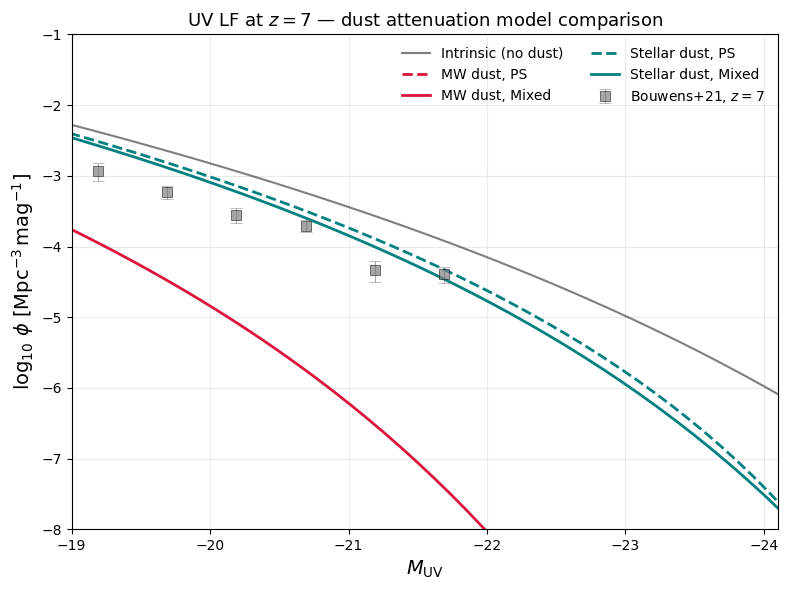

In [ ]:
from astropy.cosmology import Planck18 as _cosmo

z_lf = 7.0

# ── Park+18 parameters ──────────────────────────────────────────────────────
KUV    = 1.15e-28            # Kennicutt: SFR [M☉/yr] = L_UV [erg/s/Hz] * KUV
OMm    = _cosmo.Om0
OMl    = _cosmo.Ode0
Omb    = _cosmo.Ob0
hlittle = _cosmo.h
H0_h   = _cosmo.H0.value / 100.0   # dimensionless h

fs_ts  = 0.15                # f★ / t★  (calibrated to match z~7 UV LF)
alpha_p = 0.3                # SFR power-law slope
Mturn  = 1e9                 # duty-cycle turnover mass [M☉]

# Hubble rate at z=7 [yr⁻¹] — Park+18 eq.
Hz_yr  = 3.09 * H0_h * (OMm * (1 + z_lf)**1.5 + OMl**0.5)

# Halo mass grid
masse  = 10.0 ** np.arange(8.0, 13.5, 0.05)   # M☉

# ── Intrinsic MUV ────────────────────────────────────────────────────────────
SFR    = fs_ts * (masse / 1e10)**(alpha_p + 1) * (Omb / OMm) * Hz_yr  # M☉/yr
L_UV   = SFR / KUV                                                      # erg/s/Hz
MUV_intr = -(np.log10(L_UV) - 0.4 * 51.63) / 0.4

# ── Halo mass function dn/dMh [Mpc⁻³ M☉⁻¹] ─────────────────────────────────
dndm = halo_mass_function(masse, z_lf)

# Duty cycle
f_duty = np.exp(-Mturn / masse)

# Jacobian |dMh / dMUV_intr| (analytical, Park+18 style)
dSFRdMh   = fs_ts * (Omb / OMm) * Hz_yr * (alpha_p + 1) * (masse / 1e10)**alpha_p / 1e10
dLUVdSFR  = 1.0 / KUV
dMUVdLUV  = -1.0 / (0.4 * np.log(10) * L_UV)
dMUVdMh_intr = dMUVdLUV * dLUVdSFR * dSFRdMh

phi_intr = dndm * f_duty * np.abs(1.0 / dMUVdMh_intr)

# ── Dust attenuation ──────────────────────────────────────────────────────────
eps_star = 0.15           # star-formation efficiency
f_d      = 4e-3           # dust-to-stellar-mass ratio
spin_mean = np.exp(-3.6)  # mean halo spin parameter

M_star = eps_star * (Omb / OMm) * masse
M_dust = f_d * M_star
R_d    = np.array([disk_scale_length(z_lf, m, spin_mean) for m in masse])  # kpc

# Σ_d [g/cm²]
Sigma_d = M_dust * const.M_sun / ((4.0 / 3.0) * np.pi * R_d**2 * const.kpc**2)

# τ_UV for each dust model
tau_UV_mw = kUV_drn      * Sigma_d
tau_UV_st = kUV_hir * Sigma_d

# A_UV [mag] for each (dust model) × (geometry)
A_UV_mw_ps  = -2.5 * np.log10(transmission_sphere(tau_UV_mw,
               omega=omega_1500_drn, g=g_1500_drn))
A_UV_mw_mix = -2.5 * np.log10(transmission_sphere_mixed(tau_UV_mw))
A_UV_st_ps  = -2.5 * np.log10(transmission_sphere(tau_UV_st,
               omega=omega_1500_hir, g=g_1500_hir))
A_UV_st_mix = -2.5 * np.log10(transmission_sphere_mixed(tau_UV_st))

MUV_mw_ps  = MUV_intr + A_UV_mw_ps
MUV_mw_mix = MUV_intr + A_UV_mw_mix
MUV_st_ps  = MUV_intr + A_UV_st_ps
MUV_st_mix = MUV_intr + A_UV_st_mix

def _phi_att(MUV_att):
    dMUV_dMh = np.gradient(MUV_att, masse)
    return dndm * f_duty * np.abs(1.0 / dMUV_dMh)

phi_mw_ps  = _phi_att(MUV_mw_ps)
phi_mw_mix = _phi_att(MUV_mw_mix)
phi_st_ps  = _phi_att(MUV_st_ps)
phi_st_mix = _phi_att(MUV_st_mix)

import pandas as _pd_lf
from dust_jwst_highz.visualization import PLOTTING_STYLES

def _plot_obs_z7(ax):
    """Plot z=7 UV LF data (Bouwens+21) in log10(phi) space."""
    bouw = _pd_lf.read_csv(DATA_DIR / "Bouwens21_z2-9.csv", comment="#")
    bouw7 = bouw[bouw["redshift"] == 7].copy()
    for col in ("phi", "err_phi_low", "err_phi_up"):
        bouw7[col] = _pd_lf.to_numeric(bouw7[col], errors="coerce")
    is_ul = np.isnan(bouw7["err_phi_up"].values) | (bouw7["err_phi_up"].values > bouw7["phi"].values)
    det   = bouw7[~is_ul]
    if len(det):
        phi    = det["phi"].values
        phi_lo = np.clip(phi - det["err_phi_low"].values, 1e-12, None)
        phi_hi = phi + det["err_phi_up"].values
        ax.errorbar(
            det["MUV"], np.log10(phi),
            yerr=[np.log10(phi / phi_lo), np.log10(phi_hi / phi)],
            fmt="s", color="grey", ms=7, mec="black", mew=0.5,
            capsize=4, elinewidth=0.8, alpha=0.7,
            label=r"Bouwens+21, $z=7$",
        )

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(MUV_intr, np.log10(phi_intr), color="black", lw=1.5, ls="-",
        label="Intrinsic (no dust)", zorder=10, alpha=0.5)

ax.plot(MUV_mw_ps,  np.log10(phi_mw_ps),  color="crimson", lw=2, ls="--",
        label="MW dust, PS")
ax.plot(MUV_mw_mix, np.log10(phi_mw_mix), color="crimson", lw=2, ls="-",
        label="MW dust, Mixed")
ax.plot(MUV_st_ps,  np.log10(phi_st_ps),  color="teal",    lw=2, ls="--",
        label="Stellar dust, PS")
ax.plot(MUV_st_mix, np.log10(phi_st_mix), color="teal",    lw=2, ls="-",
        label="Stellar dust, Mixed")

_plot_obs_z7(ax)

ax.set_xlabel(r"$M_{\rm UV}$", fontsize=14)
ax.set_ylabel(r"$\log_{10}\,\phi\ [\mathrm{Mpc}^{-3}\,\mathrm{mag}^{-1}]$", fontsize=14)
ax.set_xlim(-19.0, -24.1)
ax.set_ylim(-8, -1)
ax.legend(fontsize=10, frameon=False, ncol=2, loc="upper right")
ax.set_title(rf"UV LF at $z={z_lf:.0f}$ — dust attenuation model comparison", fontsize=13)
ax.grid(alpha=0.25)
plt.tight_layout()
#fig.savefig(DATA_DIR / "../outputs/fig_uvlf_dust_comparison_z7.pdf", bbox_inches="tight")
plt.show()

## Section 3: Σ_d and M_UV distributions — morphology and ISM turbulence

For a single representative halo (log Mh = 11.6), we decompose Σ_d scatter into:

1. **Galaxy-to-galaxy scatter (spin parameter λ)**: disk size r_d ∝ λ × r_vir,
   so compact galaxies (low λ) are dustier per unit area by ~0.5 dex.
   This is *morphological* uncertainty — identical halos can have very different τ.

2. **LOS scatter (turbulent Mach number M)**: within one galaxy, turbulence creates
   a log-normal distribution of Σ_d along different sight lines.
   Width σ_ln ∝ √(ln(1 + R M²/4)).  Higher M → more low-τ sight lines → UV-bright tail.

**Tension with JWST**: the excess of UV-bright galaxies at z ~ 7–10 can be explained
by porous, turbulent ISMs (M ~ 10–100) that let UV photons escape from dusty halos.

PDF plot parameters: log_mh=11.6, eps_star=0.15, f_d=0.004, z=7.0
Intrinsic MUV at log Mh=11.6: -22.39


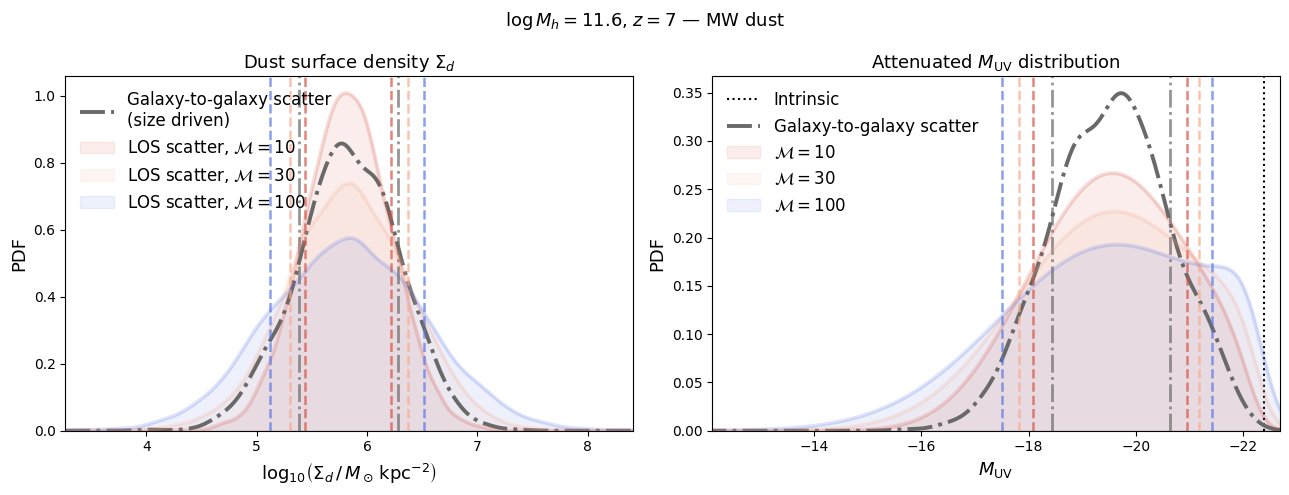

In [ ]:
from scipy.stats import norm, gaussian_kde
from dust_jwst_highz.model.ism import lognormal_variance_from_mach, sample_surface_density

# --- Representative-halo parameters (local copies — independent of LF loop globals) ---
log_mh_rep     = 11.6
_eps_star_rep  = eps_star   # star-formation efficiency (from Section 5, same value)
_f_d_rep       = f_d        # dust-to-stellar-mass ratio (from Section 5, same value)
print(f"PDF plot parameters: log_mh={log_mh_rep}, eps_star={_eps_star_rep}, f_d={_f_d_rep}, z={z_lf}")
mh_rep = 10**log_mh_rep

sfr_rep = fs_ts * (mh_rep / 1e10)**(alpha_p + 1) * (Omb / OMm) * Hz_yr
l1500_rep = sfr_rep / KUV
muv_intr_rep = -(np.log10(l1500_rep) - 0.4 * 51.63) / 0.4
print(f"Intrinsic MUV at log Mh={log_mh_rep}: {muv_intr_rep:.2f}")

m_star_rep = _eps_star_rep * (Omb / OMm) * mh_rep
m_dust_rep  = _f_d_rep * m_star_rep

np.random.seed(42)
spin_rep = np.random.lognormal(mean=np.log(10**-1.5677), sigma=0.5390, size=1000)
r_d_rep  = np.array([disk_scale_length(z_lf, mh_rep, lam) for lam in spin_rep])
Sigmad_arr_rep = m_dust_rep * const.M_sun / ((4.0/3.0) * np.pi * r_d_rep**2 * const.kpc**2)

mach_vals_pdf = np.array([10, 30, 100])
Sigmad_clumpy = {m: sample_surface_density(mu_sigma=np.median(Sigmad_arr_rep), mach=m)
                 for m in mach_vals_pdf}

tau_rep_spin = kUV_drn * Sigmad_arr_rep
muv_att_spin = -2.5 * np.log10(l1500_rep * transmission_sphere_mixed(tau_rep_spin)) + 51.63

K_SPINS = 13
N_LOS   = 600
_u_left  = (np.arange(1, K_SPINS // 2 + 1) - 0.5) / K_SPINS
u_seeds  = np.concatenate([_u_left, [0.5], 1.0 - _u_left[::-1]])

def _get_muv_clumpy(mach, sigmad_arr, u_seeds, n_los, kappa_uv, l_intr):
    sigma_ln  = lognormal_variance_from_mach(mach)
    mu_sigmas = np.quantile(sigmad_arr, u_seeds)
    u_los     = (np.arange(1, n_los + 1) - 0.5) / n_los
    z_los     = norm.ppf(u_los)[None, :]
    sig_los   = np.exp(np.log(mu_sigmas)[:, None] + sigma_ln * z_los)
    luv_los   = l_intr * transmission_sphere_mixed(kappa_uv * sig_los)
    return -2.5 * np.log10(luv_los.ravel()) + 51.63

muv_clumpy_pdf = {m: _get_muv_clumpy(m, Sigmad_arr_rep, u_seeds, N_LOS,
                                      kUV_drn, l1500_rep)
                  for m in mach_vals_pdf}

cmap_mach = plt.cm.coolwarm_r
mach_colors_pdf = [cmap_mach(v) for v in [0.1, 0.3, 0.9]]

gcm2_to_msun_kpc2 = const.kpc**2 / const.M_sun
log_sig_spin    = np.log10(Sigmad_arr_rep * gcm2_to_msun_kpc2)
log_sig_clumpy  = {m: np.log10(Sigmad_clumpy[m] * gcm2_to_msun_kpc2) for m in mach_vals_pdf}

all_log_sig = np.concatenate([log_sig_spin] + [log_sig_clumpy[m] for m in mach_vals_pdf])
x_sig = np.linspace(all_log_sig.min(), all_log_sig.max(), 400)

all_muv_pdf = np.concatenate([muv_att_spin] + [muv_clumpy_pdf[m] for m in mach_vals_pdf])
x_muv_pdf   = np.linspace(min(all_muv_pdf.min(), muv_intr_rep) - 0.3, all_muv_pdf.max(), 400)

fig, (ax_sig, ax_muv) = plt.subplots(1, 2, figsize=(13, 5))

sig_data   = [log_sig_spin] + [log_sig_clumpy[m] for m in mach_vals_pdf]
muv_data   = [muv_att_spin] + [muv_clumpy_pdf[m] for m in mach_vals_pdf]
colors_pdf = ["dimgrey"] + list(mach_colors_pdf)
labels_sig = ["Galaxy-to-galaxy scatter\n(size driven)"] + \
             [fr"LOS scatter, $\mathcal{{M}}={m}$" for m in mach_vals_pdf]
labels_muv = ["Galaxy-to-galaxy scatter"] + \
             [fr"$\mathcal{{M}}={m}$" for m in mach_vals_pdf]

for i, (logs, col, lab) in enumerate(zip(sig_data, colors_pdf, labels_sig)):
    kde = gaussian_kde(logs)
    pdf = kde(x_sig)
    p16, p84 = np.percentile(logs, [16, 84])
    if i == 0:
        ax_sig.plot(x_sig, pdf, color=col, lw=2.8, ls="-.", label=lab)
        ax_sig.axvline(p16, color=col, lw=2.0, ls="-.", alpha=0.7)
        ax_sig.axvline(p84, color=col, lw=2.0, ls="-.", alpha=0.7)
    else:
        ax_sig.fill_between(x_sig, 0, pdf, color=col, alpha=0.1, label=lab, zorder=-1000 + i)
        ax_sig.plot(x_sig, pdf, color=col, lw=2.8, alpha=0.2)
        ax_sig.axvline(p16, color=col, ls="--", lw=1.8, alpha=0.7)
        ax_sig.axvline(p84, color=col, ls="--", lw=1.8, alpha=0.7)

ax_sig.set_xlabel(r"$\log_{10}\!\left(\Sigma_d\,/\,M_\odot\,\mathrm{kpc}^{-2}\right)$", fontsize=13)
ax_sig.set_ylabel("PDF", fontsize=13)
ax_sig.set_xlim(x_sig.min(), x_sig.max())
ax_sig.set_ylim(bottom=0)
ax_sig.legend(frameon=False, fontsize=12, loc="upper left")
ax_sig.set_title(r"Dust surface density $\Sigma_d$", fontsize=13)

ax_muv.axvline(muv_intr_rep, color="black", ls=":", lw=1.5, label="Intrinsic")
for i, (arr, col, lab) in enumerate(zip(muv_data, colors_pdf, labels_muv)):
    kde = gaussian_kde(arr)
    pdf = kde(x_muv_pdf)
    p16, p84 = np.percentile(arr, [16, 84])
    if i == 0:
        ax_muv.plot(x_muv_pdf, pdf, color=col, lw=2.8, ls="-.", label=lab)
        ax_muv.axvline(p16, color=col, lw=2.0, ls="-.", alpha=0.7)
        ax_muv.axvline(p84, color=col, lw=2.0, ls="-.", alpha=0.7)
    else:
        ax_muv.fill_between(x_muv_pdf, 0, pdf, color=col, alpha=0.1, label=lab)
        ax_muv.plot(x_muv_pdf, pdf, color=col, lw=2.8, alpha=0.2)
        ax_muv.axvline(p16, color=col, ls="--", lw=1.8, alpha=0.7)
        ax_muv.axvline(p84, color=col, ls="--", lw=1.8, alpha=0.7)

ax_muv.set_xlabel(r"$M_{\rm UV}$", fontsize=13)
ax_muv.set_ylabel("PDF", fontsize=13)
ax_muv.set_xlim(x_muv_pdf.max(), x_muv_pdf.min())
ax_muv.set_ylim(bottom=0)
ax_muv.legend(frameon=False, fontsize=12, loc="upper left")
ax_muv.set_title(r"Attenuated $M_{\rm UV}$ distribution", fontsize=13)

plt.suptitle(fr"$\log M_h = {log_mh_rep}$, $z = {z_lf:.0f}$ — MW dust", fontsize=13)
plt.tight_layout()
#fig.savefig(DATA_DIR / "../outputs/fig_sigmad_muv_pdfs_z7.pdf", bbox_inches="tight")
plt.show()

## Section 4: Turbulent UV LF — porous ISM and the bright-end excess

Replace the single Σ_d per halo with a log-normal distribution whose width combines
(i) geometry/spin scatter and (ii) turbulent ISM (Mach number), added in quadrature.

**Method**: for each halo the fraction of LOS brighter than M_UV is the CDF of the
log-normal Σ_d distribution, giving a smooth φ(M_UV) via:

  φ(M_UV) = ∫ (dn/d log Mh) × |df/dM_UV| d log Mh

**Result**: higher Mach number creates a broader, brighter UV LF.  A porous ISM with
M ~ 10–100 reconciles the predicted and observed bright-end counts at z=7
without requiring unusually low dust masses.

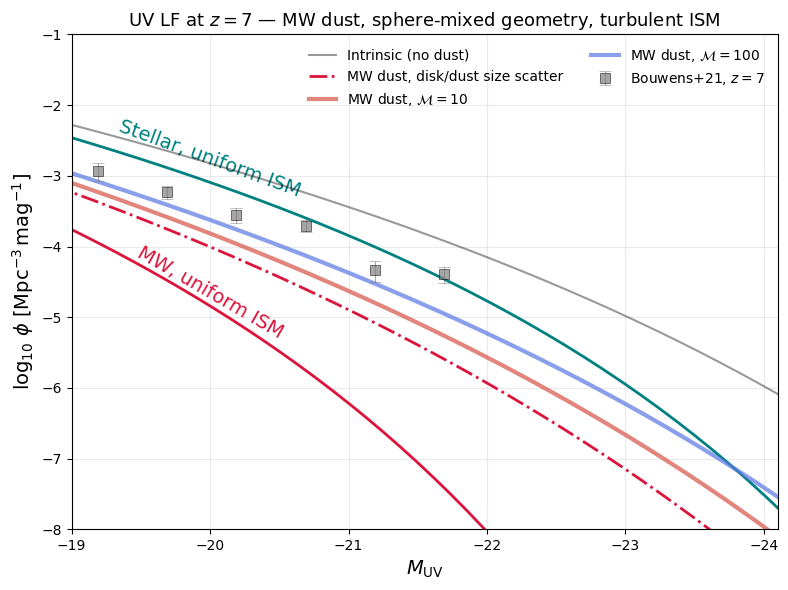

In [ ]:
from scipy.special import erf
from scipy.signal import savgol_filter

# K_SPINS quantile seeds for geometry scatter (same scheme as main.py fig9)
K_SPINS_LF  = 21
mu_ln_sp    = np.log(10**-1.5677)
sig_ln_sp   = 0.5390
_ul         = (np.arange(1, K_SPINS_LF // 2 + 1) - 0.5) / K_SPINS_LF
u_lf        = np.concatenate([_ul, [0.5], 1.0 - _ul[::-1]])
spin_quant_lf = np.exp(mu_ln_sp + norm.ppf(u_lf) * sig_ln_sp)

# τ(T) lookup — start at 1e-3 to avoid T_sphere_mixed(0) undefined
tau_lu_grid = np.linspace(1e-3, 20.0, 4000)
T_lu_grid   = transmission_sphere_mixed(tau_lu_grid)
_T_rev      = T_lu_grid[::-1]
_tau_rev    = tau_lu_grid[::-1]

def _tau_of_T(t):
    return np.interp(np.clip(t, _T_rev[0], _T_rev[-1]), _T_rev, _tau_rev)

def _nz(x):
    return np.where(np.abs(x) < 1e-6, np.sign(x) * 1e-6, x)

# Halo mass function in log-space [Mpc^-3 dex^-1]
dn_dlogm_lf = halo_mass_function(masse, z_lf) * masse * np.log(10)
log_masse    = np.log10(masse)

kappa_UV = float(kUV_drn)

# Geometry scatter: per-halo (Σ₀, σ_geom) from K_SPINS spin quantiles
Sigma0_lf     = np.empty(len(masse))
sigma_geom_lf = np.empty(len(masse))
for j, Mh in enumerate(masse):
    m_d   = f_d * eps_star * (Omb / OMm) * Mh
    r_d_k = np.array([disk_scale_length(z_lf, Mh, lam) for lam in spin_quant_lf])
    Sig_k = m_d * const.M_sun / ((4.0/3.0) * np.pi * r_d_k**2 * const.kpc**2)
    ln_s  = np.log(Sig_k)
    Sigma0_lf[j]     = np.exp(np.mean(ln_s))
    sigma_geom_lf[j] = np.std(ln_s)

MUV_grid_lf = np.linspace(MUV_intr.min() - 0.5, MUV_intr.max() + 2.0, 300)
n_m_lf      = len(MUV_grid_lf)
n_mh_lf     = len(masse)

mach_lf_vals = [0, 10, 100]
phi_turb = {}

for mach in mach_lf_vals:
    sigma_turb_lf = lognormal_variance_from_mach(mach) if mach > 0 else 0.0
    sigma_eff_lf  = np.sqrt(sigma_geom_lf**2 + sigma_turb_lf**2)

    df_dm = np.zeros((n_mh_lf, n_m_lf))
    for j in range(n_mh_lf):
        M_int_j  = MUV_intr[j]
        Sig0_j   = Sigma0_lf[j]
        sigma_j  = sigma_eff_lf[j]
        if not (np.isfinite(Sig0_j) and Sig0_j > 0 and sigma_j > 0):
            continue

        T_star  = 10**(-0.4 * (MUV_grid_lf - M_int_j))
        valid_t = (T_star > 0) & (T_star <= 1.0)
        tau_max = np.zeros(n_m_lf)
        if np.any(valid_t):
            tau_max[valid_t] = _tau_of_T(T_star[valid_t])
        Sig_max = tau_max / kappa_UV

        f_mj = np.zeros(n_m_lf)
        pos  = Sig_max > 0
        if np.any(pos):
            z_ln       = (np.log(Sig_max[pos]) - np.log(Sig0_j)) / (np.sqrt(2.0) * sigma_j)
            f_mj[pos]  = 0.5 * (1.0 + erf(z_ln))

        df       = np.zeros(n_m_lf)
        df[1:-1] = (f_mj[2:] - f_mj[:-2]) / _nz(MUV_grid_lf[2:] - MUV_grid_lf[:-2])
        df[0]    = (f_mj[1] - f_mj[0])    / _nz(MUV_grid_lf[1]  - MUV_grid_lf[0])
        df[-1]   = (f_mj[-1] - f_mj[-2])  / _nz(MUV_grid_lf[-1] - MUV_grid_lf[-2])
        df_dm[j, :] = df

    phi_c = np.array([np.trapezoid(dn_dlogm_lf * df_dm[:, i], log_masse) for i in range(n_m_lf)])

    logphi   = np.log10(np.clip(phi_c, 1e-12, None))
    win_m    = max(11, min(41, (n_m_lf // 3) * 2 + 1))
    logphi_s = savgol_filter(logphi, win_m, 3, mode="interp")
    phi_s = 10**logphi_s
    for _i in range(1, len(phi_s)):
        if phi_s[_i] < phi_s[_i - 1]:
            phi_s[_i] = phi_s[_i - 1]
    phi_turb[mach] = phi_s

_mach_plot = [10, 100]
_mach_cols = [plt.cm.coolwarm_r(v) for v in [0.1, 0.9]]

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(MUV_intr, np.log10(phi_intr), color="black", lw=1.5, ls="-",
        label="Intrinsic (no dust)", zorder=10, alpha=0.4)

ax.plot(MUV_mw_mix, np.log10(phi_mw_mix), color="crimson", lw=2, ls="-")
ax.plot(MUV_st_mix, np.log10(phi_st_mix), color="teal",    lw=2, ls="-")

fig.canvas.draw()
ax.text(-20.0, -5.3, "MW, uniform ISM", color="crimson", fontsize=14,
        ha="center", rotation=-30)
ax.text(-20.0, -3.3, "Stellar, uniform ISM", color="teal", fontsize=14,
        ha="center", rotation=-20)

ax.plot(MUV_grid_lf, np.log10(phi_turb[0]), color="crimson", lw=2, ls="-.",
        label=r"MW dust, disk/dust size scatter")

for mach, col in zip(_mach_plot, _mach_cols):
    ax.plot(MUV_grid_lf, np.log10(phi_turb[mach]), color=col, lw=3, ls="-",
            alpha=0.7, label=fr"MW dust, $\mathcal{{M}}={mach}$")

_plot_obs_z7(ax)

ax.set_xlabel(r"$M_{\rm UV}$", fontsize=14)
ax.set_ylabel(r"$\log_{10}\,\phi\ [\mathrm{Mpc}^{-3}\,\mathrm{mag}^{-1}]$", fontsize=14)
ax.set_xlim(-19.0, -24.1)
ax.set_ylim(-8, -1)
ax.legend(fontsize=10, frameon=False, ncol=2, loc="upper right")
ax.set_title(rf"UV LF at $z={z_lf:.0f}$ — MW dust, sphere-mixed geometry, turbulent ISM", fontsize=13)
ax.grid(alpha=0.25)
plt.tight_layout()
#fig.savefig(DATA_DIR / "../outputs/fig_uvlf_turbulent_z7.pdf", bbox_inches="tight")
plt.show()

## Section 5: IR LF at z=7 — why does the IR matter?

**The UV alone is degenerate.** A UV-bright galaxy could be:
1. Truly dust-poor (low M_dust, low τ), *or*
2. Dusty but with a porous ISM — most LOS are clear, but the absorbed fraction
   is non-negligible and the reprocessed emission shows up in the FIR

Adding **IR constraints breaks this degeneracy**: a simultaneous UV + FIR detection
requires the ISM to have both transparent and opaque LOS (porous/turbulent geometry).
Under **radiative transfer equilibrium**, all absorbed UV is re-emitted in the FIR:

  L_IR = A_abs × L_UV,ν × ν_1500    [erg/s]
  A_abs = 1 − T_mixed(τ_abs),   τ_abs = κ_abs × Σ_d

Using κ_abs (not κ_ext) isolates the *absorbed* fraction — scattered photons do not heat dust.
MW dust (κ_abs,MW > κ_abs,stellar) predicts larger L_IR at fixed M_UV.

**REBELS context**: many z~7 galaxies are detected in both rest-UV (JWST/HST) and
158 µm continuum (ALMA). Their simultaneous UV brightness and IR emission is naturally
explained by a porous ISM — not by them being dust-free.

In [ ]:
# UV frequency at 1500 Å
nu_1500 = 3e10 / 1500e-8   # Hz

# τ_abs for each dust model (absorption only — not scattering)
tau_abs_mw = kUV_drn_abs      * Sigma_d
tau_abs_st = kUV_hir_abs * Sigma_d

# Absorbed fraction
A_abs_mw_mix = 1.0 - transmission_sphere_mixed(tau_abs_mw)
A_abs_st_mix = 1.0 - transmission_sphere_mixed(tau_abs_st)

# L_IR [L_sun]
LIR_mw_mix = A_abs_mw_mix * L_UV * nu_1500 / const.L_sun
LIR_st_mix = A_abs_st_mix * L_UV * nu_1500 / const.L_sun

# Protect against zeros/negatives
LIR_mw_mix = np.where(LIR_mw_mix > 0, LIR_mw_mix, np.nan)
LIR_st_mix = np.where(LIR_st_mix > 0, LIR_st_mix, np.nan)

logLIR_mw = np.log10(LIR_mw_mix)
logLIR_st = np.log10(LIR_st_mix)

# LF from Jacobian: phi = (dn/d log Mh) / |d log LIR / d log Mh|
dn_dlogm_ir = halo_mass_function(masse, z_lf) * masse * np.log(10)

def _phi_ir(logLIR):
    dlogLIR_dlogm = np.gradient(logLIR, log_masse)
    dlogLIR_dlogm = np.where(np.abs(dlogLIR_dlogm) < 1e-6,
                              np.sign(dlogLIR_dlogm) * 1e-6, dlogLIR_dlogm)
    return dn_dlogm_ir * f_duty / np.abs(dlogLIR_dlogm)

phi_ir_mw = _phi_ir(logLIR_mw)
phi_ir_st = _phi_ir(logLIR_st)

# ── REBELS Barrufet+23 IR LF data ────────────────────────────────────────────
rebels_ir = _pd_lf.read_csv(DATA_DIR / "REBELS_z7_IR_LF_Barrufet23.csv", comment="#")
phi_reb   = 10 ** rebels_ir["log_phi"].values
phi_uerr  = 10 ** (rebels_ir["log_phi"] + rebels_ir["log_phi_err_high"]).values - phi_reb
phi_lerr  = phi_reb - 10 ** (rebels_ir["log_phi"] - rebels_ir["log_phi_err_low"]).values
phi_lerr  = np.minimum(phi_lerr, 0.99 * phi_reb)
phi_uerr  = np.minimum(phi_uerr, 0.99 * phi_reb)

## Section 5 & 6: Combined IR LF — uniform and turbulent ISM

Single comparison plot with four predictions:
- **MW dust, uniform ISM** (crimson solid): upper envelope from fully processed grains
- **Stellar dust, uniform ISM** (teal solid): lower envelope from freshly produced grains
- **MW dust, disk/size scatter** (crimson dash-dot): morphological uncertainty from spin λ
- **MW dust, Mach=10** (blue): turbulent ISM — boosts variance in A_abs,
  reshaping the bright end of the IR LF

**Key constraint**: the IR LF amplitude distinguishes dust models even when the
UV LFs look similar. At a given UV brightness, MW dust produces ~2–3× more IR emission
than stellar dust. Combining both wavelengths therefore pins down not just the dust
abundance but also the grain composition/evolution stage.

Observational constraints: REBELS z=7 IR LF from Barrufet+23.

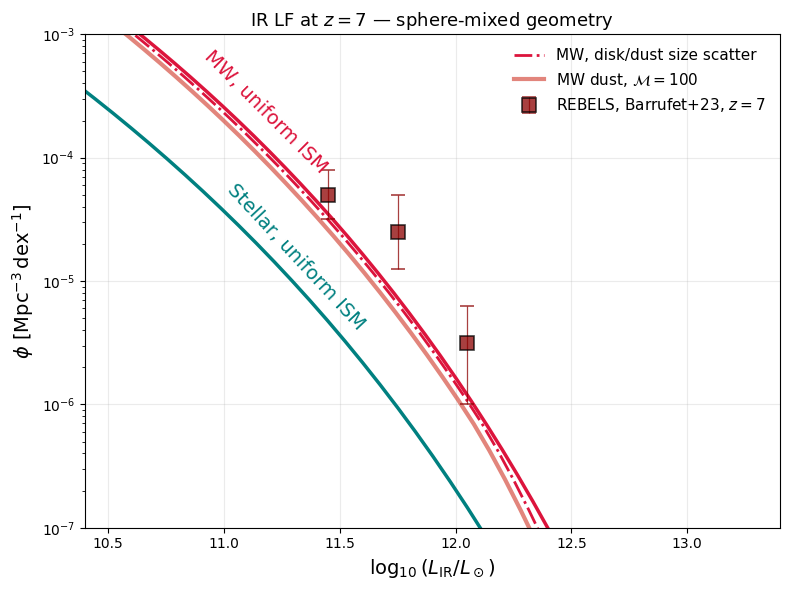

In [ ]:
# Gauss–Legendre nodes in u∈(0,1) space, mapped to z-space via norm.ppf
K_GL = 24
xu_gl, wu_gl = np.polynomial.legendre.leggauss(K_GL)
u_gl   = np.clip(0.5 * (xu_gl + 1.0), 1e-12, 1 - 1e-12)
w_gl   = 0.5 * wu_gl
z_gl   = norm.ppf(u_gl)

# Compute turbulent IR LF for size-scatter (mach=0) and Mach=10 only
phi_ir_turb = {}
for mach in [0, 100]:
    sigma_turb = lognormal_variance_from_mach(mach) if mach > 0 else 0.0

    LIR_med = np.empty(len(masse))
    for j, Mh in enumerate(masse):
        Sig0_j  = Sigma0_lf[j]
        sigma_j = np.sqrt(sigma_geom_lf[j]**2 + sigma_turb**2)
        if not (np.isfinite(Sig0_j) and Sig0_j > 0 and sigma_j > 0):
            LIR_med[j] = np.nan
            continue
        x_nodes   = Sig0_j * np.exp(sigma_j * z_gl)
        T_abs_nod = transmission_sphere_mixed(kUV_drn_abs * x_nodes)
        f_abs     = np.sum(w_gl * (1.0 - T_abs_nod))
        LIR_med[j] = f_abs * L_UV[j] * nu_1500 / const.L_sun

    LIR_med = np.where(LIR_med > 0, LIR_med, np.nan)
    log_lir = np.log10(LIR_med)

    dlogLIR_dlogm = np.gradient(log_lir, log_masse)
    dlogLIR_dlogm = np.where(np.abs(dlogLIR_dlogm) < 1e-6,
                              np.sign(dlogLIR_dlogm) * 1e-6, dlogLIR_dlogm)
    phi_raw = dn_dlogm_ir * f_duty / np.abs(dlogLIR_dlogm)
    phi_raw = np.where(np.isfinite(phi_raw) & (phi_raw > 0), phi_raw, np.nan)

    logphi_r  = np.log10(np.clip(phi_raw, 1e-12, None))
    win_ir    = max(11, min(41, (len(logphi_r) // 3) * 2 + 1))
    phi_ir_turb[mach]          = 10 ** savgol_filter(logphi_r, win_ir, 3, mode="interp")
    phi_ir_turb[(mach, "lir")] = log_lir

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

# Uniform ISM — crimson (MW) and teal (Stellar), inline labels
ax.semilogy(logLIR_mw, phi_ir_mw, color="crimson", lw=2.5, ls="-")
ax.semilogy(logLIR_st, phi_ir_st, color="teal",    lw=2.5, ls="-")

# Inline text labels (placed at the faint end of each curve)
_i_mw = np.nanargmin(np.abs(logLIR_mw - 11.2))
ax.text(10.9, 7e-5,
        "MW, uniform ISM", color="crimson", fontsize=14, ha="left", va="bottom", rotation=-45)
_i_st = np.nanargmin(np.abs(logLIR_st - 11.2))
ax.text(11., 6.5e-5,
        "Stellar, uniform ISM", color="teal", fontsize=14, ha="left", va="top", rotation=-47)

# Disk/size scatter — crimson dash-dot
ax.semilogy(phi_ir_turb[(0, "lir")], phi_ir_turb[0], color="crimson", lw=2, ls="-.",
            label=r"MW, disk/dust size scatter")

# Mach=10 — coolwarm_r blue, matching UV LF
ax.semilogy(phi_ir_turb[(100, "lir")], phi_ir_turb[100],
            color=plt.cm.coolwarm_r(0.1), lw=3, ls="-", alpha=0.7,
            label=fr"MW dust, $\mathcal{{M}}=100$")

# REBELS Barrufet+23
ax.errorbar(rebels_ir["log_LIR"], phi_reb, yerr=[phi_lerr, phi_uerr],
            ls="none", marker="s", ms=10, capsize=5, alpha=0.75,
            color="darkred", mec="black", mew=1.2, elinewidth=0.9,
            label=r"REBELS, Barrufet+23, $z=7$")

ax.set_yscale("log")
ax.set_ylim(1e-7, 1e-3)
ax.set_xlim(10.4, 13.4)
ax.set_xlabel(r"$\log_{10}(L_{\rm IR}/L_\odot)$", fontsize=14)
ax.set_ylabel(r"$\phi\ [\mathrm{Mpc}^{-3}\,\mathrm{dex}^{-1}]$", fontsize=14)
ax.legend(frameon=False, fontsize=11, loc="upper right")
ax.set_title(rf"IR LF at $z={z_lf:.0f}$ — sphere-mixed geometry", fontsize=13)
ax.grid(alpha=0.25)
plt.tight_layout()
#fig.savefig(DATA_DIR / "../outputs/fig_irlf_z7.pdf", bbox_inches="tight")
plt.show()

## Section 7: Greybody FIR SED — T_dust, CMB heating, and ALMA detectability

The SED is where UV and IR observations are most directly compared:
a single T_dust model predicts the full observed spectrum.

**Why the SED adds constraining power beyond the LF:**
- The *shape* of the SED (peak wavelength) constrains T_dust independently of L_IR
- T_dust depends on both L_IR/M_dust *and* the grain κ at FIR wavelengths
  → MW vs stellar dust predict different T_dust at the same L_IR/M_dust
- CMB heating at high-z reduces the observable contrast, especially for cool dust:
  a detection tells you T_dust > T_CMB(z) ≈ 22 K at z=7
- ALMA band sensitivity (shown as shaded regions) determines which galaxies are detectable

**Forward model** (seed-averaged turbulent L_IR → T_dust via greybody inversion):

  L_IR = M_d κ_158 (8π/c²) (ν_0^{-β}) (k_B/h)^{4+β} Γ(4+β) ζ(4+β) T_d^{4+β}
  F_ν(λ_obs) [µJy] = (1+z)/D_L² × M_d κ_λ × [B_ν(T_d^{CMB}) − B_ν(T_CMB)]

β_d = 2.03, κ_λ = κ_158 (λ/158 µm)^{-β_d} (Draine+03 silicates)

REBELS data (Inami+22): individual z ≈ 6.5–7.7 galaxies detected at rest-frame
158 µm, colour-coded by stellar mass. Shaded bands show ALMA Bands 6–9 (observed frame).

→ MW dust (WD01), M=100: log(LIR/Lsun)=11.20, Td=32.6 K
→ Stellar dust (H19), M=100: log(LIR/Lsun)=10.93, Td=37.0 K


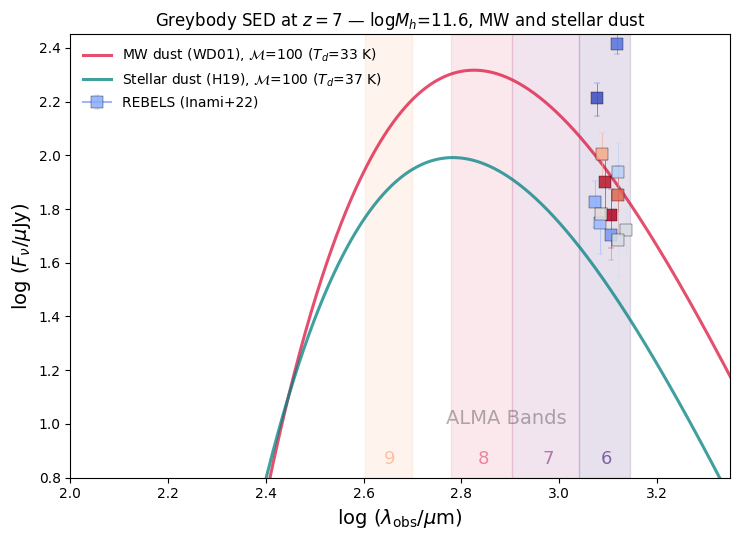

In [ ]:
from dust_jwst_highz.model.dust import greybody_dust_temp, dust_temp_from_lir, seedavg_lir
from dust_jwst_highz.model.luminosity import greybody_fnu

bd = 2.03   # dust emissivity index β_d (Draine+03 silicates)

# ── Dust model configurations ─────────────────────────────────────────────────
_sed_models = [
    {"name": "MW dust (WD01)",     "color": "crimson", "kUV_abs": kUV_drn_abs, "kIR": kIR_drn},
    {"name": "Stellar dust (H19)", "color": "teal",    "kUV_abs": kUV_hir_abs, "kIR": kIR_hir},
]
_mach_sed = [100]
_ls_mach  = {100: "-"}

# Wavelength grids (observed frame)
lam_obs_um  = np.logspace(2, 4, 2000)
lam_rest_um = lam_obs_um / (1.0 + z_lf)
lam_rest_cm = lam_rest_um * 1e-4

# ── REBELS individual galaxy data (Inami+22, Sommovigo+22) ──────────────────────────────
# 158 µm continuum flux [µJy] and observed redshifts for 13 REBELS galaxies
_reb_mstar = np.array([10.09, 9.56, 9.94, 9.22, 9.82, 9.38, 10.27,
                        10.16, 10.04, 9.78, 10.37, 9.24, 9.82])
_reb_z     = np.array([6.496, 6.749, 7.346, 7.084, 7.675, 7.370, 7.307,
                        7.090, 6.685, 6.729, 6.577, 6.845, 7.365])
_reb_flux  = np.array([67.23, 101.44, 86.78, 59.99, 52.87, 71.15, 259.55,
                        50.59, 56.08, 60.38, 163.00, 79.74, 48.28])   # µJy
_reb_eflux = np.array([13., 20., 24., 15., 10., 20., 22., 10., 13., 17., 23., 16., 13.])

# Colour normalization based on actual REBELS M★ range
_cmap_sed  = plt.cm.coolwarm_r
_mstar_lo  = _reb_mstar.min()
_mstar_hi  = _reb_mstar.max()
def _sed_col(log_ms):
    return _cmap_sed((log_ms - _mstar_lo) / (_mstar_hi - _mstar_lo))

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7.5, 5.5))

for _mod in _sed_models:
    for _mach in _mach_sed:
        LIR = seedavg_lir(_mod["kUV_abs"], _mach, Sigmad_arr_rep, l1500_rep)
        Td  = dust_temp_from_lir(LIR, m_dust_rep, _mod["kIR"])
        print(f'\u2192 {_mod["name"]}, M={_mach}: log(LIR/Lsun)={np.log10(LIR / const.L_sun):.2f}, Td={Td:.1f} K')
        Fnu = greybody_fnu(lam_rest_cm, Td, np.log10(m_dust_rep), z_lf, _mod["kIR"])
        ax.plot(np.log10(lam_obs_um), np.log10(Fnu),
                color=_mod["color"], ls=_ls_mach[_mach], lw=2.2, alpha=0.75,
                label=fr'{_mod["name"]}, $\mathcal{{M}}$={_mach} ($T_d$={Td:.0f} K)')

# REBELS data (colour-coded by log M★, normalised over the REBELS M★ range)
for jj in range(len(_reb_z)):
    Fo, dFo = _reb_flux[jj], _reb_eflux[jj]
    ax.errorbar(
        np.log10(158.0 * (1.0 + _reb_z[jj])), np.log10(Fo),
        yerr=[[np.log10(Fo / max(Fo - dFo, 1e-3))], [np.log10((Fo + dFo) / Fo)]],
        ms=9, marker="s", capsize=2.5, mec="black", elinewidth=0.5,
        color=_sed_col(_reb_mstar[jj]), mew=0.3, alpha=0.85,
        label="REBELS (Inami+22)" if jj == 0 else None,
    )

# ALMA band fills
_magma = plt.cm.magma(np.linspace(0.2, 0.8, 4))
_yr    = [0.8, 2.45]
for _lo, _hi, _col, _lab in [
    (1.1e3, 1.4e3, _magma[0], "6"),
    (0.8e3, 1.1e3, _magma[1], "7"),
    (0.6e3, 0.8e3, _magma[2], "8"),
    (0.4e3, 0.5e3, _magma[3], "9"),
]:
    ax.fill_betweenx(_yr, np.log10(_lo), np.log10(_hi), color=_col, alpha=0.12, zorder=-100)
    ax.text(np.log10(0.5 * (_lo + _hi)), _yr[0] + 0.05, _lab,
            fontsize=13, color=_col, alpha=0.6, ha="center")

ax.text(np.log10(0.78e3),1., "ALMA Bands", fontsize=14, alpha=0.3, ha="center")

ax.set_xlim(2.0, 3.35)
ax.set_ylim(*_yr)
ax.set_xlabel(r"$\log\,(\lambda_{\rm obs}/\mu{\rm m})$", fontsize=14)
ax.set_ylabel(r"$\log\,(F_\nu/\mu{\rm Jy})$", fontsize=14)
ax.legend(frameon=False, fontsize=10, loc="upper left")
ax.set_title(
    rf"Greybody SED at $z={z_lf:.0f}$ — log$M_h$={log_mh_rep}, MW and stellar dust",
    fontsize=12,
)
plt.tight_layout()
plt.show()
